In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import wine_common as wine
import nn_common as nnc
import torch
import torch.nn as nn
import importlib
from functools import partial
import pandas as pd
import copy
from sklearn.model_selection import KFold, StratifiedKFold
import svm_common as sc

importlib.reload(nnc)
importlib.reload(wine)

<module 'wine_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/wine_common.py'>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

<h5>Parameters</h5>
<p>Parameters useful for dataset preparation</p>

In [3]:
# The wine type red,white or join (a common joined red+white dataset)
wine_type="white"
# None or an array with wine quality to exclude from dataset [i.e. 3,8,9]
quality_filter=None

# The seed to be used by data splitter
default_state = 42

# Subset is derived from data analysis
# and feature selection, more for learning purpose
# than for real needs as the number of features is small
subset_features_1 = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'total sulfur dioxide'
]

<h5>Split and prepare</h5>
<p>Dataset is prepared and splitted in two normalized (with MinMaxScaler) datasets: train and test.</p>

In [4]:
importlib.reload(wine)
df_train, df_test = wine.stratified_split(type=wine_type, seed=default_state, quality_filter=quality_filter)
X_tr_full, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
X_tr = X_tr_full[subset_features_1]
X_ts = X_ts[subset_features_1]
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,3919,979
1,Number of features,11,11
2,Class values,"[3, 4, 5, 6, 7, 8, 9]","[3, 4, 5, 6, 7, 8]"
3,Class balance,"quality 3 = 15, quality 4 = 138, quality 5 = 1...","quality 3 = 5, quality 4 = 25, quality 5 = 291..."


<h4>Network Architecture</h4>
<p>Defining the neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [5]:
# Starting learning rate
learning_rate = 1e-1

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]


# Defining network architecture
# For simplicity we start with just one hidden layer with small nr of hidden unit
hidden_unit = 5
net = nn.Sequential(
    # 1st Hidden Layer
    nn.Linear(input_dimension, hidden_unit, bias=True), # <- NET
    nn.ReLU(), # <- Activation function
    #nn.Tanh(), # <- Activation function

    # Output layer
    # The output layer is kept linear in order to decouple
    # the network architecture from the choice of the loss function
    # and the prediction phase
    nn.Linear(hidden_unit, 1, bias=True) # <- NET
)

# The output and loss function, must be changed according to the type of task
loss_function = nn.MSELoss()
output_adapter = nnc.regression_mse_adapter()

# Model implementation
model_template = nnc.MLP(net, output_adapter)
# weights initialization (for didactic purposes)
model_template.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

# The weight update algorithm
# optimizer_template = partial(
#     torch.optim.Adam,
#     lr = default_learning_rate,
#     weight_decay = 1e-4
# )

# optimizer_template = partial(
#     torch.optim.AdamW,
#     lr = default_learning_rate,
#     weight_decay = 1e-4
# )

optimizer_template = partial(
    torch.optim.SGD,
    #lr = 0.5,
    lr = learning_rate,
    #momentum = default_momentum,
    #nesterov = default_nesterov,
    #weight_decay = 1e-4
)

# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)

print(model_template)

MLP(
  (_net): Sequential(
    (0): Linear(in_features=5, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)


In [6]:


# default_weight_decay = 1e-4
# default_batch_size = 256
#
# #Epochs
# default_epochs=300
# # Early stopping (-1 or < 0 = disabled)
# default_patience=-1
#
default_seed = 1
# default_min_delta = 1e-4
#
# # Custom Hyperparameters
# default_momentum = 0.5
# default_nesterov = True
#
# default_random_state = 42



<h3>NN Run</h3>
<hr/>

<h4>Hold-out</h4>
<p>Training model and prediction according to hold-out strategy.</p>

<h5>Training</h5>
<p>Training the model.</p>

In [7]:
importlib.reload(nnc)

# custom settings
ho_batch_size=256
ho_epochs=300
# Enabling Early stopping
ho_min_delta = 1e-4
ho_patience = 50

# Clone an untrained model and its optimizer
model_ho = copy.deepcopy(model_template)

train_result = nnc.train(
    model_ho, X_tr, y_tr, optimizer_template, loss_function,
    batch_size=ho_batch_size, epochs=ho_epochs,
    min_delta=ho_min_delta,
    patience=ho_patience,
    seed=default_seed,
    scheduler_template=scheduler_template
)


hist_tr = train_result["hist_tr"]
hist_vl = train_result["hist_vl"]
hist_grad = train_result["hist_grad"]

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 300
Train           | samples: 3136
Validation      | samples: 783
Batch type      | mini-batch (256)
Loss algorithm  | MSELoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.1}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | patience: 50 , minimum delta: 0.0001
----------------------------------------------------------------------------------------------------
Early stopping at epoch 199 (best VL loss: 0.6161)


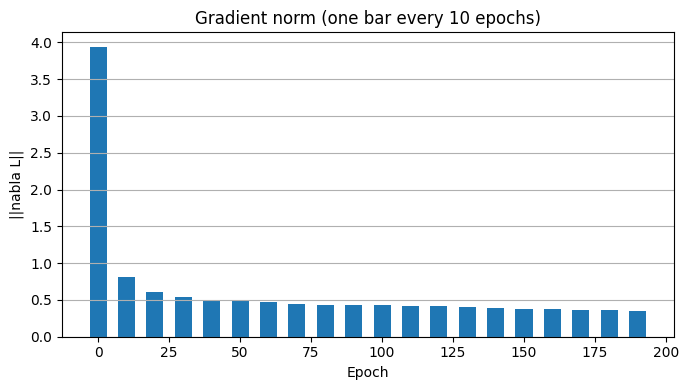

In [8]:
importlib.reload(nnc)
nnc.plot_gradient_norm_bars(hist_grad, step=10)

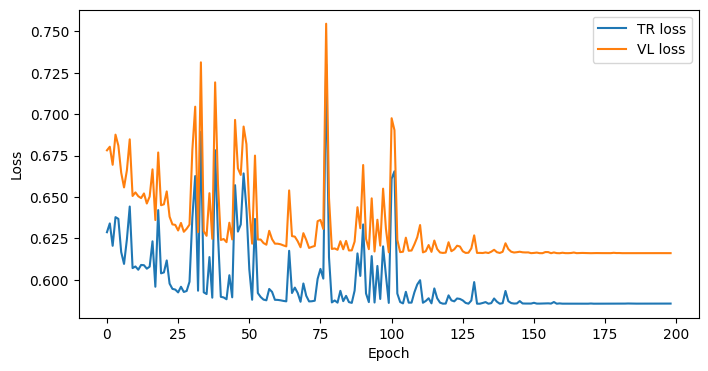

In [9]:
nnc.plot_epoch_loss(hist_tr, hist_vl)

<h5>Prediction</h5>
<p>Prediction with the official test set.</p>

In [10]:
importlib.reload(nnc)
all_pred = nnc.predict(model_ho, X_ts)

#y_pred = pd.DataFrame(all_pred[0].detach().cpu().numpy())
y_pred = all_pred[0].detach().cpu().numpy().squeeze()
#y_pred = np.rint(y_pred).astype(int)
#y_pred = np.clip(y_pred, 2, 10)  # es. 3..9


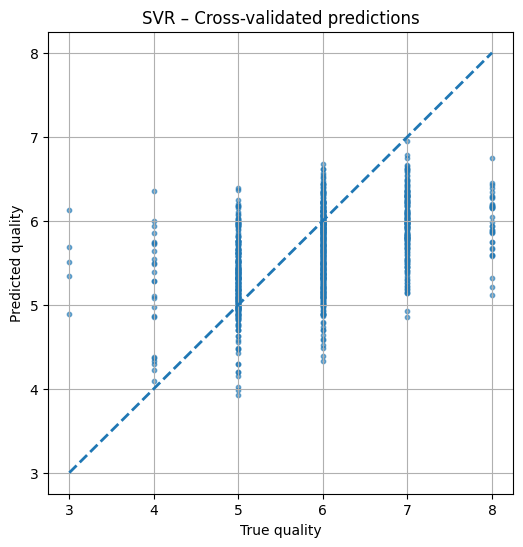

In [11]:
sc.plot_true_vs_preds_svr(y_ts, y_pred)

In [12]:
sc.regression_report(y_ts, y_pred)

   true_quality  support  mean_pred       MAE      RMSE      bias
0             3        5   5.513852  2.513852  2.546372  2.513852
1             4       25   5.200478  1.200478  1.353893  1.200478
2             5      291   5.301975  0.413800  0.522984  0.301975
3             6      431   5.659732  0.438110  0.553943 -0.340267
4             7      192   5.950068  1.049932  1.121859 -1.049932
5             8       35   5.973754  2.026245  2.057552 -2.026245


<hr/>

<h4>KFold</h4>
<p>Perform training and validation according to KFold strategy.</p>

<h5>Parameters</h5>
<p>The number of epoch has been increased in respect to hold-out validation, but early stopping have also been enabled to avoid overfitting.</p>
<p>The StratifiedKFold has been choosed as it tryies to keep a balance between classes.</p>

In [17]:
importlib.reload(nnc)
# StratifiedKFold when shuffle=True shuffle the samples keeping a balance between them
# Passing a random_state permit reproducible output across multiple function calls
kv_random_state=42
#kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=kv_random_state)

# Epochs
kv_epochs=500
kv_batch_size=64
# Disable Early stopping
kv_min_delta = 1e-4
kv_patience = -1

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    "seed": default_seed,
}

fold_histories = nnc.run_kfold(
    model_template, X_tr, y_tr, optimizer_template, scheduler_template, loss_function, kf, inner_train_params
)


  
Perform fold: 0, train size: 3135, val size: 784
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 2508
Validation      | samples: 627
Batch type      | mini-batch (64)
Loss algorithm  | MSELoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.1}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 3135, val size: 784
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 2508
Validation      | samples: 627
Batch type      | mini-batch (64)
Loss algorithm  | MSELoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0

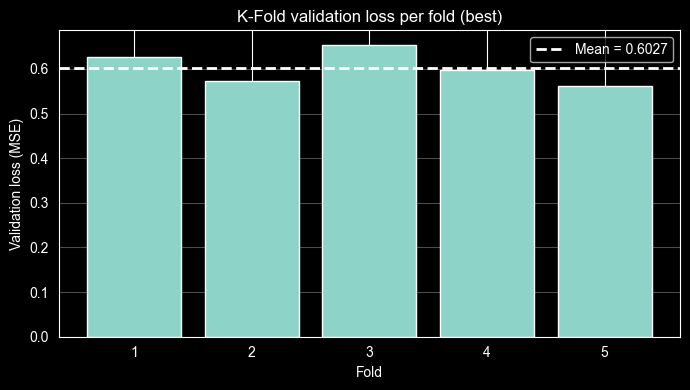

In [18]:
importlib.reload(nnc)
nnc.plot_kfold_bar_vl_loss(fold_histories, use="best")

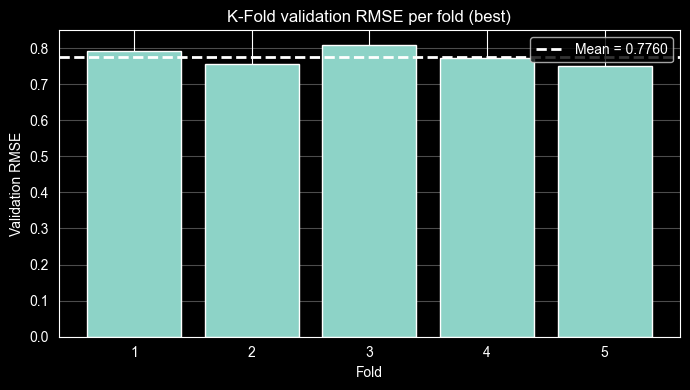

In [19]:
importlib.reload(nnc)
nnc.plot_kfold_bar_vl_rmse(fold_histories, use="best")

In [20]:
importlib.reload(nnc)
df_kfold = nnc.kfold_regression_table(
    fold_histories,
    use="best",
    derive_rmse=True
)

        TR_MSE    VL_MSE  Gap(TR-VL)   TR_RMSE   VL_RMSE
Fold                                                    
1     0.540936  0.626851    0.085915  0.735483  0.791739
2     0.560270  0.573351    0.013081  0.748512  0.757200
3     0.577306  0.653777    0.076471  0.759807  0.808565
4     0.574023  0.596766    0.022743  0.757643  0.772506
5     0.564773  0.562701   -0.002072  0.751514  0.750134
MEAN  0.563462  0.602689    0.039227  0.750592  0.776029
STD   0.014340  0.037712    0.039458  0.009593  0.024202


<h5>Training</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [27]:
# dopo aver scelto best_params dal KFold
model_kf = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_kf, X_tr, y_tr, optimizer_template, loss_function,
    epochs=inner_train_params['epochs'], batch_size=inner_train_params['batch_size'],scheduler_template=scheduler_template,
    seed=inner_train_params['seed'], patience=inner_train_params.get('patience',0), min_delta=inner_train_params.get('min_delta',None))

hist_kf_tr = train_kf_result["hist_tr"]
hist_kf_vl = train_kf_result["hist_vl"]
hist_kf_grad = train_kf_result["hist_grad"]

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 3136
Validation      | samples: 783
Batch type      | mini-batch (64)
Loss algorithm  | MSELoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.1}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.0001}
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

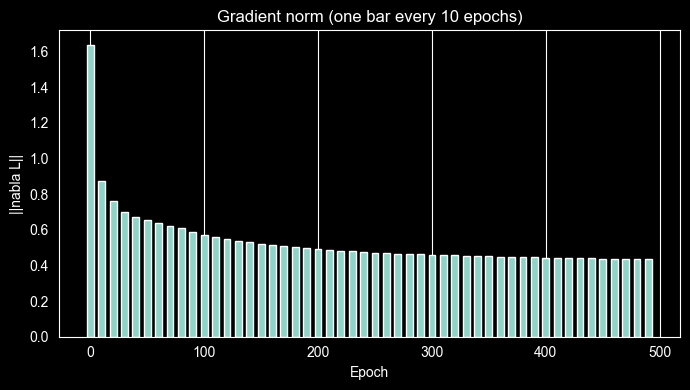

In [28]:
nnc.plot_gradient_norm_bars(hist_kf_grad, step=10)

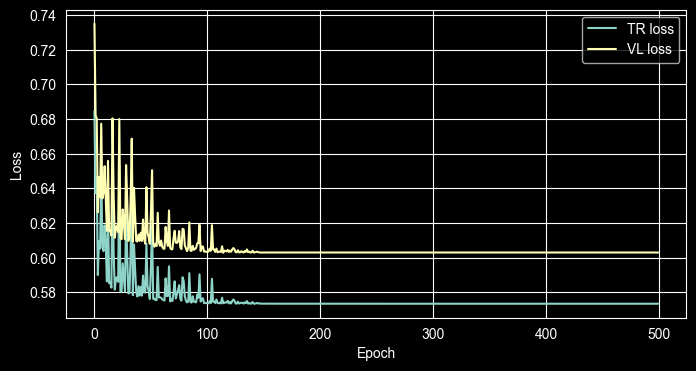

In [29]:
nnc.plot_epoch_loss(hist_kf_tr, hist_kf_vl)

<h5>Prediction</h5>
<p>Prediction with the official test set.</p>

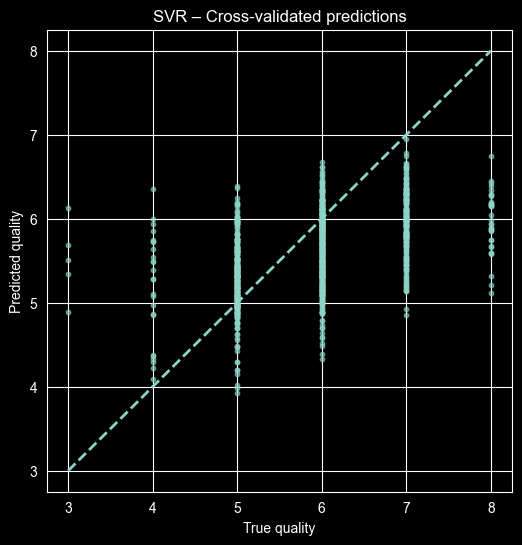

In [32]:
all_kf_pred = nnc.predict(model_kf, X_ts)
y_kf_pred = pd.DataFrame(all_pred[0].detach().cpu().numpy())
sc.plot_true_vs_preds_svr(y_ts, y_kf_pred)